In [ ]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

--2025-04-16 09:19:54--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.199.207, 74.125.20.207, 108.177.98.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.199.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   186MB/s    in 0.6s    

2025-04-16 09:19:55 (186 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [ ]:
# !unzip pizza_steak.zip

In [ ]:
# zip_ref=zipfile.ZipFile('/content/pizza_steak.zip','r')
# zip_ref.extractall()
# zip_ref.close()

In [ ]:
with zipfile.ZipFile('/content/pizza_steak.zip','r') as zip_ref:
    zip_ref.extractall()

In [ ]:
!ls /content/pizza_steak/test

pizza  steak


In [ ]:
import os
for dirpath,dirnames,filenames in os.walk('/content/pizza_steak'):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in "{dirpath}".')

There are 2 directories and 0 images in "/content/pizza_steak".
There are 2 directories and 0 images in "/content/pizza_steak/test".
There are 0 directories and 250 images in "/content/pizza_steak/test/steak".
There are 0 directories and 250 images in "/content/pizza_steak/test/pizza".
There are 2 directories and 0 images in "/content/pizza_steak/train".
There are 0 directories and 750 images in "/content/pizza_steak/train/steak".
There are 0 directories and 750 images in "/content/pizza_steak/train/pizza".


In [ ]:
num_pizza_images_train=os.listdir('/content/pizza_steak/train/pizza')
len(num_pizza_images_train)

750

In [ ]:
import matplotlib.pyplot as plt
import random
import pathlib
import matplotlib.image as mpimg

def view_random_image(target_dir,target_class):
    target_folder=pathlib.Path(target_dir) / target_class
    random_image = random.choice(os.listdir(target_folder))
    random_image_path = os.path.join(target_folder, random_image)
    img=mpimg.imread(random_image_path)
    plt.imshow(img)
    plt.title(target_class)
    plt.axis('off')
    print(f"Image shape {img.shape}")

Image shape (512, 512, 3)


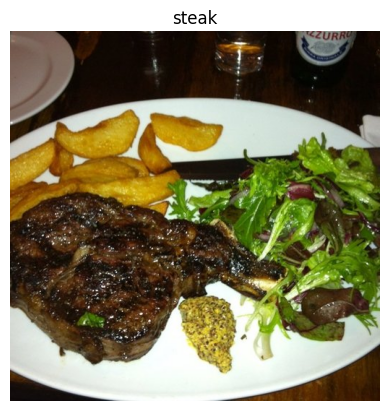

In [ ]:
view_random_image(target_dir='/content/pizza_steak/test',target_class='steak')

In [ ]:
import tensorflow as tf

IMG_size=(224,224)
train_dir='/content/pizza_steak/train'
test_dir='/content/pizza_steak/test'

train_data=tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                               label_mode='binary',
                                                               image_size=IMG_size,
                                                               color_mode='rgb',
                                                               batch_size=32,
                                                               shuffle=True)
test_data=tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                              label_mode='binary',
                                                              image_size=IMG_size)

Found 1500 files belonging to 2 classes.
Found 500 files belonging to 2 classes.


In [ ]:
class_names=train_data.class_names
class_names

['pizza', 'steak']

In [ ]:
train_data=train_data.cache('/tmp/train_data').prefetch(buffer_size=tf.data.AUTOTUNE)
test_data=test_data.cache('/tmp/test_data').prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.Conv2D(filters=64,kernel_size=7,strides=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=1,activation='sigmoid')
])

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer=tf.keras.optimizers.SGD(momentum=0.9,learning_rate=0.001))
model.fit(train_data,epochs=5,validation_data=test_data)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 357ms/step - accuracy: 0.5280 - loss: 0.8226 - val_accuracy: 0.6980 - val_loss: 0.6220
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.6295 - loss: 0.6415 - val_accuracy: 0.7480 - val_loss: 0.5287
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.7048 - loss: 0.5756 - val_accuracy: 0.7720 - val_loss: 0.4971
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7176 - loss: 0.5375 - val_accuracy: 0.8200 - val_loss: 0.4150
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7464 - loss: 0.5062 - val_accuracy: 0.7920 - val_loss: 0.4233


In [ ]:
model.evaluate(train_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7841 - loss: 0.4475


[0.44265979528427124, 0.7886666655540466]

In [ ]:
model.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7932 - loss: 0.4255


[0.4233161509037018, 0.7919999957084656]

In [ ]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomHeight(0.1),
    tf.keras.layers.RandomWidth(0.1)
])

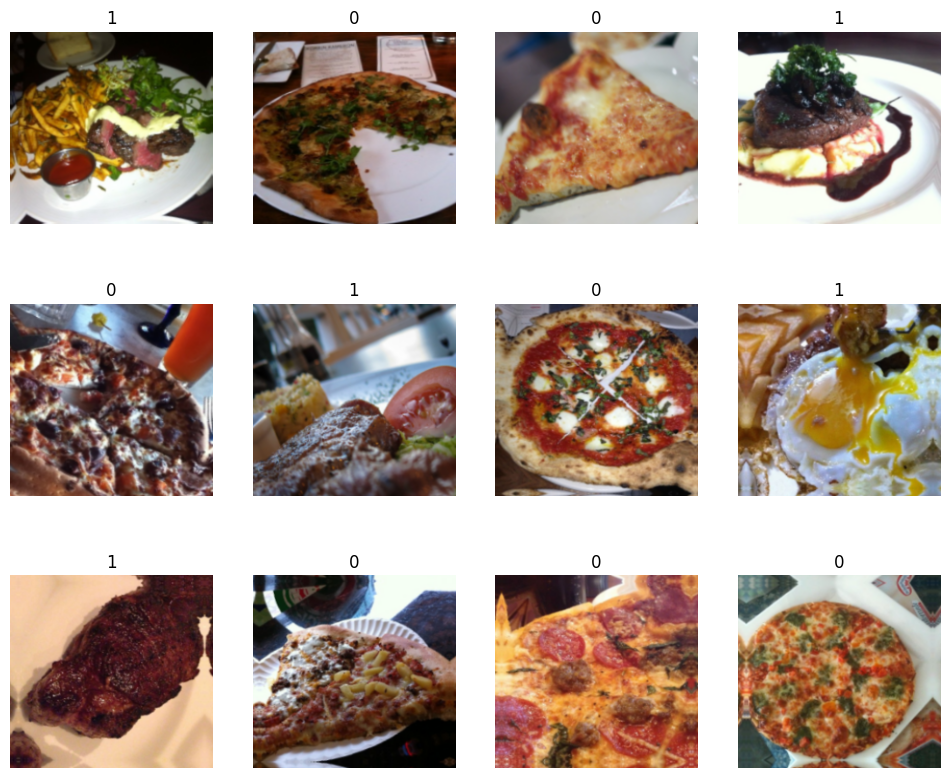

In [ ]:
for images,labels in train_data.take(1):
    augmented_images=data_augmentation(images)
    plt.figure(figsize=(12,10))
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(augmented_images[i].numpy().astype('uint8'))
        plt.title(labels[i].numpy()[0].astype('int8'))
        plt.axis('off')

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape =(224, 224, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.Resizing(224, 224),
    tf.keras.layers.Conv2D(filters = 64, kernel_size = 7, strides = 3, padding = 'same',
                           activation = 'relu', kernel_initializer = 'he_normal'),

    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same',
                           activation = 'relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same',
                           activation = 'relu', kernel_initializer='he_normal'),

        tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Conv2D(filters = 256, kernel_size = 3, padding = 'same',
                           activation = 'relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters = 256, kernel_size = 3, padding = 'same',
                           activation = 'relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(pool_size = 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation = 'relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation = 'relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=1, activation = 'sigmoid')


])

In [ ]:
model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.003),
              metrics = ['accuracy'])
model.fit(train_data, epochs = 5, validation_data = test_data)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.5187 - loss: 0.8630 - val_accuracy: 0.5960 - val_loss: 0.6542
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5771 - loss: 0.6774 - val_accuracy: 0.7220 - val_loss: 0.6354
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6202 - loss: 0.6410 - val_accuracy: 0.7140 - val_loss: 0.5926
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6501 - loss: 0.6287 - val_accuracy: 0.7620 - val_loss: 0.5587
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6353 - loss: 0.6168 - val_accuracy: 0.7780 - val_loss: 0.5535


In [ ]:
inputs = tf.keras.layers.Input(shape = (224, 224, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)

base_model = tf.keras.applications.ResNet50(include_top= False, weights= 'imagenet', input_tensor=x)

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

outputs = tf.keras.layers.Dense(units = 1, activation = "sigmoid")(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainabletraining = False

In [ ]:
model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics = ['accuracy'])
model.fit(train_data, epochs = 5, validation_data = test_data)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 810ms/step - accuracy: 0.6290 - loss: 0.6631 - val_accuracy: 0.8920 - val_loss: 0.3328
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 285ms/step - accuracy: 0.8415 - loss: 0.4157 - val_accuracy: 0.9520 - val_loss: 0.2302
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 288ms/step - accuracy: 0.9137 - loss: 0.3071 - val_accuracy: 0.9600 - val_loss: 0.1871
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 318ms/step - accuracy: 0.9493 - loss: 0.2431 - val_accuracy: 0.9660 - val_loss: 0.1636
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 293ms/step - accuracy: 0.9583 - loss: 0.2004 - val_accuracy: 0.9680 - val_loss: 0.1478


In [ ]:
initial_learning_rate = 0.01

lr_schedules = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps = 0.47,
    decay_rate = 0.96

)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  patience = 3,
                                                  restore_best_weights = True)

model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics = ['accuracy'])
model.fit(train_data, epochs = 15, validation_data = test_data, callbacks = early_stopping)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 56s 674ms/step - accuracy: 0.9684 - loss: 0.1697 - val_accuracy: 0.9700 - val_loss: 0.1357
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.9738 - loss: 0.1465 - val_accuracy: 0.9720 - val_loss: 0.1254
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step - accuracy: 0.9808 - loss: 0.1282 - val_accuracy: 0.9740 - val_loss: 0.1167
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 298ms/step - accuracy: 0.9837 - loss: 0.1135 - val_accuracy: 0.9740 - val_loss: 0.1091
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step - accuracy: 0.9897 - loss: 0.1014 - val_accuracy: 0.9740 - val_loss: 0.1026
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 293ms/step - accuracy: 0.9912 - loss: 0.0912 - val_accuracy: 0.9740 - val_loss: 0.0969
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 321ms/step - accuracy: 0.9929 - loss: 0.0826 - val_accuracy: 0.9740 - val_loss: 0.0920
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 294ms/step - accuracy: 0.9949 - loss: 0.0751 - val_accu

In [ ]:
inputs = tf.keras.Input(shape = (224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.resnet50.preprocess_input(x)

base_model = tf.keras.applications.ResNet50(include_top= False, weights= 'imagenet', input_tensor=x)


x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)


outputs = tf.keras.layers.Dense(units = 1, activation = 'sigmoid')(x)

model = tf.keras.Model(inputs = inputs, outputs = outputs)

In [ ]:
base_model.trainable = False

In [ ]:
initial_learning_rate = 0.01

lr_schedules = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps = 0.47,
    decay_rate = 0.96

)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  patience = 3,
                                                  restore_best_weights = True)

model.compile(loss = 'binary_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.001),
              metrics = ['accuracy'])
model.fit(train_data, epochs = 15, validation_data = test_data, callbacks = early_stopping)

Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 704ms/step - accuracy: 0.5526 - loss: 0.7225 - val_accuracy: 0.8360 - val_loss: 0.4076
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 431ms/step - accuracy: 0.8306 - loss: 0.4261 - val_accuracy: 0.9300 - val_loss: 0.2540
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 328ms/step - accuracy: 0.8973 - loss: 0.3207 - val_accuracy: 0.9560 - val_loss: 0.1900
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 356ms/step - accuracy: 0.9211 - loss: 0.2638 - val_accuracy: 0.9620 - val_loss: 0.1549
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 282ms/step - accuracy: 0.9307 - loss: 0.2377 - val_accuracy: 0.9720 - val_loss: 0.1324
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 287ms/step - accuracy: 0.9251 - loss: 0.2201 - val_accuracy: 0.9780 - val_loss: 0.1172
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 294ms/step - accuracy: 0.9475 - loss: 0.1919 - val_accuracy: 0.9780 - val_loss: 0.1057
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.9463 - loss: 0.1747 - val_accu